# 📊 Notebook 01 — Coleta de Dados e Análise Exploratória (EDA)

> **Objetivo geral:** Coletar séries temporais do Banco Central do Brasil (BCB) relacionadas ao mercado de crédito e fazer uma análise exploratória antes de construir modelos preditivos de inadimplência.

In [2]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install python-bcb




[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


## Importações e Primeira Série: Inadimplência Total


- `sgs.get({"inad_total": 21082}, ...)` → baixa a série **21082** do SGS/BCB, que representa a **taxa de inadimplência total da carteira de crédito** do sistema financeiro brasileiro (em %)
- `start="2019-01-01"` → coleta dados a partir de janeiro de 2019
- A data é convertida para o tipo `datetime` do pandas, garantindo manipulação correta de séries temporais

O gráfico de linha gerado mostra a **evolução da inadimplência ao longo do tempo**, com área preenchida para facilitar a visualização de tendências.

> 💡 **Conceito:** Inadimplência é o percentual de operações de crédito com atraso superior a 90 dias em relação ao total da carteira.



Dados coletados: 87 observações
Período: 2019-01-01 00:00:00 a 2026-03-01 00:00:00
Inadimplência atual: 4.33%


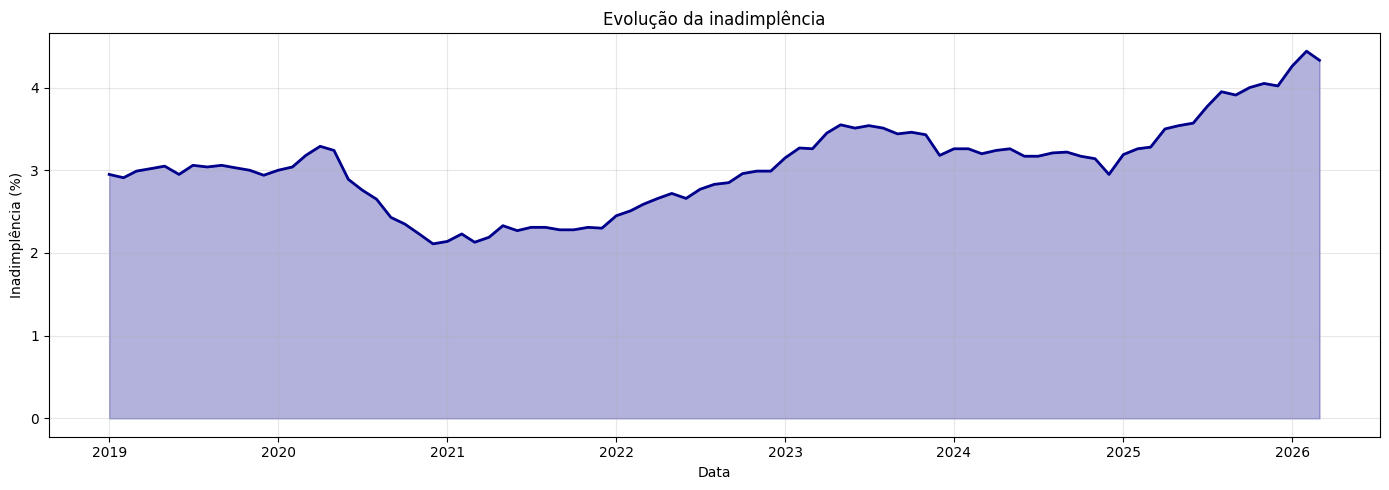

,data,inad_total
82,2025-11-01,4.05
83,2025-12-01,4.02
84,2026-01-01,4.26
85,2026-02-01,4.44
86,2026-03-01,4.33


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from bcb import sgs
import warnings
warnings.filterwarnings('ignore')

# Série-alvo
inad_total = sgs.get({"inad_total": 21082}, start="2019-01-01")
inad_total = inad_total.reset_index()
inad_total.columns = ["data", "inad_total"]
inad_total["data"] = pd.to_datetime(inad_total["data"])

print(f"Dados coletados: {len(inad_total)} observações")
print(f"Período: {inad_total['data'].min()} a {inad_total['data'].max()}")
print(f"Inadimplência atual: {inad_total['inad_total'].iloc[-1]:.2f}%")

plt.figure(figsize=(14, 5))
plt.plot(inad_total["data"], inad_total["inad_total"], linewidth=2, color="darkblue")
plt.fill_between(inad_total["data"], inad_total["inad_total"], alpha=0.3, color="darkblue")
plt.xlabel("Data")
plt.ylabel("Inadimplência (%)")
plt.title("Evolução da inadimplência")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

inad_total.tail()

## Construção da Base de Dados

A base deste notebook contém somente a **série-alvo**: a inadimplência total da carteira de crédito do sistema financeiro brasileiro (SGS/BCB, código 21082).

As variáveis exógenas macroeconômicas (saldo, concessões, juros, Selic, IPCA) são tratadas no **Notebook 02**, que constrói o modelo base de predição. Mantê-las aqui misturaria o papel da análise exploratória da variável-alvo com a análise de preditores, dificultando a interpretação.

O objetivo desta seção é organizar a série mensal de inadimplência no período de análise.

In [5]:
DATA_INICIO = "2019-01-01"

df_base = sgs.get({"inad_total": 21082}, start=DATA_INICIO)

df_modelo = df_base.reset_index()
df_modelo.columns = ["data", "inad_total"]
df_modelo["data"] = pd.to_datetime(df_modelo["data"])
df_modelo["mes"] = df_modelo["data"].dt.to_period("M").dt.to_timestamp()

df_modelo = (
    df_modelo.groupby("mes", as_index=False)["inad_total"]
    .mean()
    .sort_values("mes")
    .reset_index(drop=True)
)

df_modelo.head()

,mes,inad_total
0,2019-01-01,2.95
1,2019-02-01,2.91
2,2019-03-01,2.99
3,2019-04-01,3.02
4,2019-05-01,3.05


In [6]:
df_modelo = df_modelo[df_modelo["mes"] <= "2025-12-31"].copy()
df_modelo = df_modelo.dropna().reset_index(drop=True)

print(f"Período final da base: {df_modelo['mes'].min().date()} até {df_modelo['mes'].max().date()}")
print(f"Total de observações: {len(df_modelo)}")

df_modelo.head()


Período final da base: 2019-01-01 até 2025-12-01
Total de observações: 84


,mes,inad_total
0,2019-01-01,2.95
1,2019-02-01,2.91
2,2019-03-01,2.99
3,2019-04-01,3.02
4,2019-05-01,3.05


## Análise Exploratória: Visão Geral e Estatísticas

Antes de modelar, é essencial entender os dados:
- **Quantos registros?** → determina os conjuntos de treino e teste
- **Há valores faltantes?** → dados incompletos comprometem o modelo
- **Quais os tipos?** → garante que as datas sejam tratadas corretamente

As estatísticas descritivas são complementadas com:
- `mediana` → mais robusta a outliers do que a média
- `amplitude` → diferença entre máximo e mínimo
- `coef_variacao` → desvio padrão ÷ média; mede a dispersão relativa

In [7]:
print("=== VISÃO GERAL DA BASE ===")
print(f"Número de linhas: {df_modelo.shape[0]}")
print(f"Número de colunas: {df_modelo.shape[1]}")
print(f"Período da base: {df_modelo['mes'].min().date()} até {df_modelo['mes'].max().date()}")

print("\n=== TIPOS DAS VARIÁVEIS ===")
print(df_modelo.dtypes)

print("\n=== VALORES FALTANTES ===")
faltantes = df_modelo[["inad_total"]].isna().sum().to_frame("qtd_faltantes")
faltantes["pct_faltantes"] = (faltantes["qtd_faltantes"] / len(df_modelo) * 100).round(2)
print(faltantes)

print("\n=== PRIMEIRAS LINHAS ===")
print(df_modelo.head())

print("\n=== ÚLTIMAS LINHAS ===")
print(df_modelo.tail())

=== VISÃO GERAL DA BASE ===
Número de linhas: 84
Número de colunas: 2
Período da base: 2019-01-01 até 2025-12-01

=== TIPOS DAS VARIÁVEIS ===
mes           datetime64[us]
inad_total           float64
dtype: object

=== VALORES FALTANTES ===
            qtd_faltantes  pct_faltantes
inad_total              0            0.0

=== PRIMEIRAS LINHAS ===
         mes  inad_total
0 2019-01-01        2.95
1 2019-02-01        2.91
2 2019-03-01        2.99
3 2019-04-01        3.02
4 2019-05-01        3.05

=== ÚLTIMAS LINHAS ===
          mes  inad_total
79 2025-08-01        3.95
80 2025-09-01        3.91
81 2025-10-01        4.00
82 2025-11-01        4.05
83 2025-12-01        4.02


In [8]:
estatisticas = df_modelo[["inad_total"]].describe().T

estatisticas["mediana"] = df_modelo["inad_total"].median()
estatisticas["amplitude"] = estatisticas["max"] - estatisticas["min"]
estatisticas["coef_variacao"] = (estatisticas["std"] / estatisticas["mean"]).round(4)

print("=== ESTATÍSTICAS DESCRITIVAS — INADIMPLÊNCIA TOTAL ===")
print(estatisticas[[
    "count", "mean", "mediana", "std", "min", "max", "amplitude", "coef_variacao"
]].round(4))

=== ESTATÍSTICAS DESCRITIVAS — INADIMPLÊNCIA TOTAL ===
            count    mean  mediana     std   min   max  amplitude  \
inad_total   84.0  3.0032     3.04  0.4842  2.11  4.05       1.94   

            coef_variacao  
inad_total         0.1612  


## Gráfico da Série Temporal

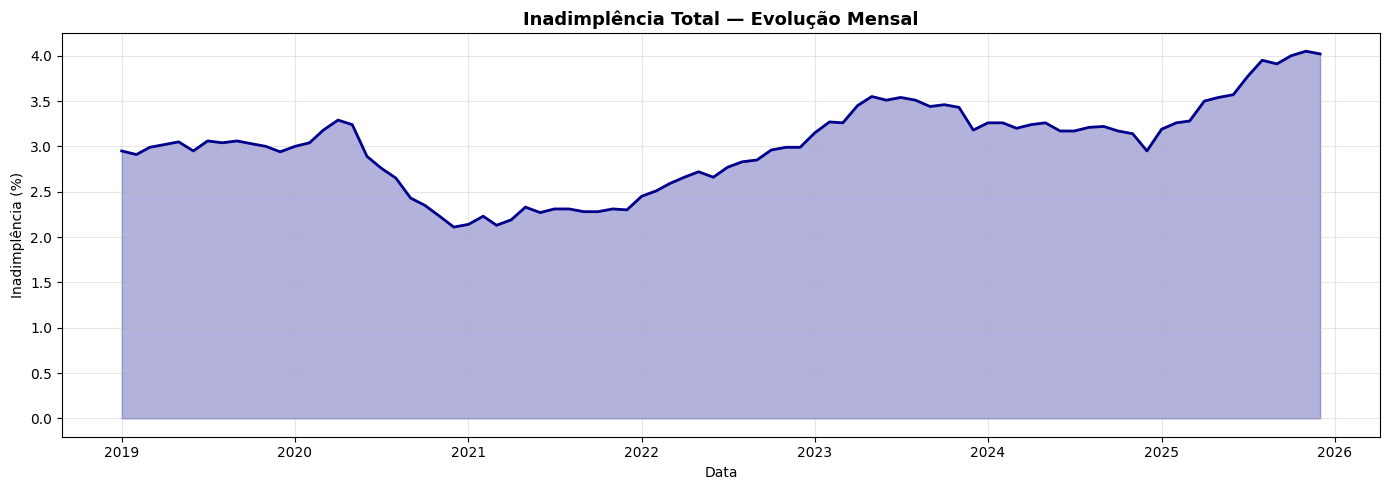

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df_modelo["mes"], df_modelo["inad_total"], linewidth=2, color="darkblue")
plt.fill_between(df_modelo["mes"], df_modelo["inad_total"], alpha=0.3, color="darkblue")
plt.title("Inadimplência Total — Evolução Mensal", fontsize=13, fontweight="bold")
plt.xlabel("Data")
plt.ylabel("Inadimplência (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Estrutura de Defasagens (Lags) da Série

Na modelagem de séries temporais, os valores passados da própria série são utilizados como preditores do valor presente — chamado de **lag** ou defasagem.

A lógica de construção segue a notação:

$$I_t \leftarrow I_{t-1}$$
$$I_t \leftarrow I_{t-1} \| I_{t-2}$$
$$I_t \leftarrow I_{t-1} \| I_{t-2} \| \ldots \| I_{t-6}$$

A tabela abaixo exibe a série presente ao lado de suas defasagens de 1 a 6 meses — exatamente como os dados são organizados como entrada do modelo.

> Cada linha traz o valor de `inad_total` no mês `t` (variável a prever) e os valores dos meses anteriores `t-1` a `t-6` (preditores).

In [13]:
df_lags = df_modelo[["mes", "inad_total"]].copy()

df_lags = df_lags.sort_values("mes").reset_index(drop=True)

df_lags = df_lags.rename(columns={
    "inad_total": "inad_total_t"
})

for lag in range(1, 7):
    df_lags[f"inad_total_L{lag}"] = df_lags["inad_total_t"].shift(lag)

print("=== SÉRIE PRESENTE E SUAS DEFASAGENS ===")
print(df_lags.round(4).to_string(index=False))

=== SÉRIE PRESENTE E SUAS DEFASAGENS ===
       mes  inad_total_t  inad_total_L1  inad_total_L2  inad_total_L3  inad_total_L4  inad_total_L5  inad_total_L6
2019-01-01          2.95            NaN            NaN            NaN            NaN            NaN            NaN
2019-02-01          2.91           2.95            NaN            NaN            NaN            NaN            NaN
2019-03-01          2.99           2.91           2.95            NaN            NaN            NaN            NaN
2019-04-01          3.02           2.99           2.91           2.95            NaN            NaN            NaN
2019-05-01          3.05           3.02           2.99           2.91           2.95            NaN            NaN
2019-06-01          2.95           3.05           3.02           2.99           2.91           2.95            NaN
2019-07-01          3.06           2.95           3.05           3.02           2.99           2.91           2.95
2019-08-01          3.04           3.06

In [14]:
print("=== AUTOCORRELAÇÃO — INADIMPLÊNCIA × SEUS LAGS ===\n")

resultados_autocorr = []
for lag in range(1, 7):
    corr = df_modelo["inad_total"].corr(df_modelo["inad_total"].shift(lag))
    resultados_autocorr.append({
        "lag": lag,
        "formula": f"I(t) <- I(t-{lag})",
        "autocorrelacao": round(corr, 4)
    })

df_autocorr = pd.DataFrame(resultados_autocorr)
print(df_autocorr.to_string(index=False))

=== AUTOCORRELAÇÃO — INADIMPLÊNCIA × SEUS LAGS ===

 lag        formula  autocorrelacao
   1 I(t) <- I(t-1)          0.9782
   2 I(t) <- I(t-2)          0.9464
   3 I(t) <- I(t-3)          0.9070
   4 I(t) <- I(t-4)          0.8474
   5 I(t) <- I(t-5)          0.7827
   6 I(t) <- I(t-6)          0.7213


In [12]:
df_lags.to_csv("base_series.csv", index=False)

print("Base exportada: base_series.csv")
print(f"Colunas: {list(df_lags.columns)}")
print(f"Observações: {len(df_lags)}")

Base exportada: base_series.csv
Colunas: ['mes', 'inad_total', 'inad_total_lag1', 'inad_total_lag2', 'inad_total_lag3', 'inad_total_lag4', 'inad_total_lag5', 'inad_total_lag6']
Observações: 78
